### Centro Universitário da Fundação Educacional Inaciana "Padre Sabóia de Medeiros" (FEI)


*FEI's Stricto Sensu Graduate Program in Electrical Engineering*

Concentration area: ARTIFICIAL INTELLIGENCE APPLIED TO AUTOMATION AND ROBOTICS

Master's thesis student Andre Luiz Florentino

***

## Check for GPU

In [1]:
import torch

# Check if CUDA (NVIDIA GPU) is available
cuda_available = torch.cuda.is_available()
print(f"CUDA available: {cuda_available}")

# If CUDA is available, print GPU details
if cuda_available:
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU: {torch.cuda.current_device()}")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB")
else:
    print("No CUDA-capable GPU found. Using CPU.")

CUDA available: True
Number of GPUs: 1
Current GPU: 0
GPU Name: NVIDIA GeForce RTX 5060 Ti
GPU Memory: 16.61 GB


# Chapter 2: Pre-processing and data exploration

ASSUMPTION: run *01_Feature_extraction_exploration.ipynb* for datasets ESC-10, BDLib2 and US8k

***

## Importe modules

In [2]:
import mimetypes
import warnings
import os
import librosa
import random
import pickle

import pandas          as pd
import numpy           as np
import seaborn         as sns
import IPython.display as ipd

from tqdm        import tqdm
from matplotlib  import pyplot as plt

In [3]:
mimetypes.init()
mimetypes.add_type('audio/ogg','.ogg')

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 300)
pd.set_option('display.max_colwidth', 120)

In [4]:
# Globals
current_path = os.getcwd()

# For the picture names
pic_first_name = '02_PreProcessing_modeling_'

# For Librosa
FRAME_SIZE  = 1024
HOP_LENGTH  = 512
SEED        = 1000
SR          = 22050

# Values for feature extraction
threshold   = 60
frames      = 44

In [5]:
current_path

'/home/saad/dev/esr-mt-andre'

## Loading the dataset


In [6]:
# Select the dataset

opc = 0
while str(opc) not in '123':
    print()
    print("1-) ESC-10")
    print("2-) BDLib2")
    print("3-) US8K")

    opc = input("\nSelect the dataset: ")
    if opc.isdigit():
        opc = int(opc)
    else:
        opc = 0

if opc == 1:

    path        = os.path.join(current_path, "_dataset", "ESC-10")
    path_pic    = os.path.join(current_path, "ESC-10_results")
    path_models = os.path.join(current_path, "ESC-10_saved_models")
    
    # Check if the folder exists, if not, create it
    if not os.path.exists(path_models):
        os.makedirs(path_models)
   
    subfolders  = next(os.walk(path))[1]
    nom_dataset = 'ESC-10' 
    csv_file    = 'ESC-10.csv'
    fold        = 1
    time_length = 5
    dog_set     = 'Dog bark'
    windowingNo = 9
    
    pkl_features           = 'ESC-10_features_original.pkl'
    pkl_aug_features      = 'ESC-10_features_augmented_no_windowing.pkl'
    pkl_aug_wind_features = 'ESC-10_features_augmented.pkl'
    
    aug_set  = True
    wind_set = True

    
if opc == 2:
    
    path        = os.path.join(current_path, "_dataset", "BDLib2")
    path_pic    = os.path.join(current_path, "BDLib2_results")
    path_models = os.path.join(current_path, "BDLib2_saved_models")
    
    # Check if the folder exists, if not, create it
    if not os.path.exists(path_models):
        os.makedirs(path_models)

    subfolders  = next(os.walk(path))[1]
    nom_dataset = 'BDLib2' 
    csv_file    = 'BDLib2.csv'
    fold        = 'fold-1'
    time_length = 10
    dog_set     = 'dogs'
    windowingNo = 19

    pkl_features          = 'BDLib2_features_original.pkl'
    pkl_aug_features      = 'BDLib2_features_augmented_no_windowing.pkl'
    pkl_aug_wind_features = 'BDLib2_features_augmented.pkl'
    
    aug_set  = True
    wind_set = True

    
if opc == 3:
    
    path        = os.path.join(current_path, "_dataset", "US8K")
    path_pic    = os.path.join(current_path, "US8K_results")
    path_models = os.path.join(current_path, "US8K_saved_models")
    
    # Check if the folder exists, if not, create it
    if not os.path.exists(path_models):
        os.makedirs(path_models)
        
    subfolders  = next(os.walk(path))[1]
    nom_dataset = 'US8K' 
    csv_file    = 'US8K.csv'
    time_length = 4
    dog_set     = 'dog_bark'
    windowingNo = 7
    
    aug_set  = False
    wind_set = True
    
    pkl_features          = 'US8K_features_original.pkl'
    pkl_aug_features      = 'US8K_features_augmented_no_windowing.pkl'
    pkl_aug_wind_features = 'US8K_features_windowed.pkl' # augmented and windowed makes no sense. Dataset is already quite large


1-) ESC-10
2-) BDLib2
3-) US8K


In [7]:
def get_next_file_number(folder: str):
    files = [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f)) and f.startswith(pic_first_name)]
    if not files:
        return 1
    else:
        numbers = [int(f.split('.')[0].split('_')[-1]) for f in files]
        return max(numbers) + 1

In [8]:
from MT_loadDataset import loadDataset

In [9]:
loadDataset = loadDataset(path)
DB          = loadDataset.db_B

print("\nClasses:\n--------------------")
print(DB["Class_categorical"].value_counts())
print("\nTotal number of unique files..........: ", len(np.unique(DB["File_name"])))
print("Total number of AUDIO files...........: ", len(DB))
DB


CSV exported.
Check the folder :  /home/saad/dev/esr-mt-andre/_dataset/ESC-10

Classes:
--------------------
Class_categorical
Clock tick        40
Person sneeze     40
Fire crackling    40
Rooster           40
Dog bark          40
Chainsaw          40
Baby cry          40
Rain              40
Sea waves         40
Helicopter        40
Name: count, dtype: int64

Total number of unique files..........:  400
Total number of AUDIO files...........:  400


,Fold,Folder_name,Class_OHEV,Class_categorical,File_name,Path,Class_ID,Clip_ID,Clip_take
0,1,005 - Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",Clock tick,1-62850-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/005 - Clock tick/1-62850-A.ogg,5,62850,A
1,3,005 - Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",Clock tick,3-150363-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/005 - Clock tick/3-150363-A.ogg,5,150363,A
2,3,005 - Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",Clock tick,3-171012-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/005 - Clock tick/3-171012-A.ogg,5,171012,A
3,2,005 - Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",Clock tick,2-88724-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/005 - Clock tick/2-88724-A.ogg,5,88724,A
4,1,005 - Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",Clock tick,1-35687-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/005 - Clock tick/1-35687-A.ogg,5,35687,A
...,...,...,...,...,...,...,...,...,...
395,2,007 - Helicopter,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]",Helicopter,2-188822-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/007 - Helicopter/2-188822-A.ogg,7,188822,A
396,5,007 - Helicopter,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]",Helicopter,5-205898-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/007 - Helicopter/5-205898-A.ogg,7,205898,A
397,3,007 - Helicopter,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]",Helicopter,3-154926-B.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/007 - Helicopter/3-154926-B.ogg,7,154926,B
398,5,007 - Helicopter,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]",Helicopter,5-191131-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/007 - Helicopter/5-191131-A.ogg,7,191131,A


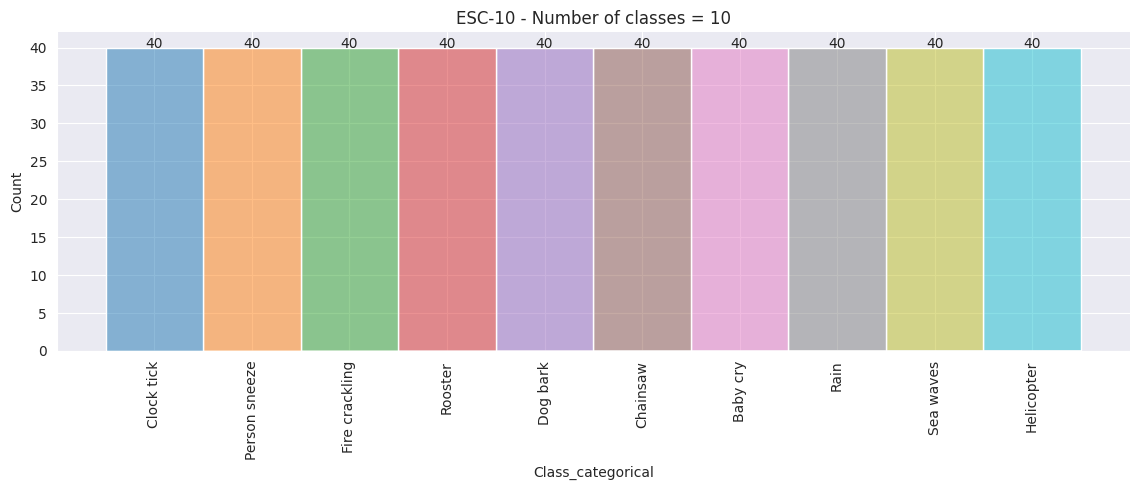

In [10]:
# Analysis of the class balancing

sns.set_style("darkgrid")
gTitle = f'{nom_dataset} - Number of classes = ' + str(len(pd.Series(DB['Class_categorical']).unique()))
g = sns.displot(DB,x='Class_categorical', hue='Class_categorical',height = 5, aspect = 2).set(title=gTitle)
g.set_xticklabels(rotation=90)
g.set_titles('Number of classes')

# Retrieve the axes object from the plot
axes = g.ax

# Iterate over each bar in the plot
for p in axes.patches:
    # Get the coordinates of the bar
    width = p.get_width()
    height = p.get_height()
    cord_x, cord_y = p.get_xy()
    if height > 0:
        axes.annotate(f'{height}', (cord_x + width/2, cord_y + height), ha='center')
        
g._legend.remove()

plt.tight_layout()

## Pre-processing the data (Features extraction)

### Exploratory code that lead to a class for extracting the features

Hand crafting the features into the dataframe

In [11]:
os.chdir(path)

In [12]:
pwd

'/home/saad/dev/esr-mt-andre/_dataset/ESC-10'

In [13]:
# Group by the class and get one random sample of each class
k = DB.groupby('Class_categorical')['Class_OHEV'].apply(lambda s: s.sample(1))
print(k)

# Convert the pandas series into a dataframe
temp_k_df = k.reset_index()

# Delete the index from the grouppby result
del temp_k_df['level_1']

# Set the "Class" as the dataframe index
temp_k_df.set_index("Class_categorical", inplace=True)

# Convert the dataframe to a dictionary (Class: Class_encoder)
encoder_dict = temp_k_df["Class_OHEV"].to_dict()
encoder_dict

Class_categorical     
Baby cry           266    [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Chainsaw           204    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
Clock tick         8      [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
Dog bark           161    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
Fire crackling     89     [0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
Helicopter         388    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
Person sneeze      40     [0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
Rain               292    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
Rooster            152    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
Sea waves          332    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
Name: Class_OHEV, dtype: object


{'Baby cry': [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 'Chainsaw': [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
 'Clock tick': [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
 'Dog bark': [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
 'Fire crackling': [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
 'Helicopter': [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
 'Person sneeze': [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
 'Rain': [0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
 'Rooster': [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
 'Sea waves': [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]}

In [14]:
type(DB['Class_OHEV'][0][0])

int

In [15]:
encoder_dict[dog_set]

[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]

In [16]:
DB

,Fold,Folder_name,Class_OHEV,Class_categorical,File_name,Path,Class_ID,Clip_ID,Clip_take
0,1,005 - Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",Clock tick,1-62850-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/005 - Clock tick/1-62850-A.ogg,5,62850,A
1,3,005 - Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",Clock tick,3-150363-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/005 - Clock tick/3-150363-A.ogg,5,150363,A
2,3,005 - Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",Clock tick,3-171012-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/005 - Clock tick/3-171012-A.ogg,5,171012,A
3,2,005 - Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",Clock tick,2-88724-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/005 - Clock tick/2-88724-A.ogg,5,88724,A
4,1,005 - Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",Clock tick,1-35687-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/005 - Clock tick/1-35687-A.ogg,5,35687,A
...,...,...,...,...,...,...,...,...,...
395,2,007 - Helicopter,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]",Helicopter,2-188822-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/007 - Helicopter/2-188822-A.ogg,7,188822,A
396,5,007 - Helicopter,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]",Helicopter,5-205898-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/007 - Helicopter/5-205898-A.ogg,7,205898,A
397,3,007 - Helicopter,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]",Helicopter,3-154926-B.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/007 - Helicopter/3-154926-B.ogg,7,154926,B
398,5,007 - Helicopter,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]",Helicopter,5-191131-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/007 - Helicopter/5-191131-A.ogg,7,191131,A


In [17]:
# Testing a method to parse each row and extract the defined audio feature

def feature_parser(row): 
    # Number of MFCCs and MELs
    n_mfcc = 13
    n_mels = 128
    
    # Load the audio file using "kaiser_fast" resampling method, otherwise use sr = 44100
    x, srate = librosa.load(row.Path, sr = SR)

    # Extract the features: RMS, ZCR 
    row['RMSE']      = np.mean(librosa.feature.rms(y                = x, hop_length = HOP_LENGTH, frame_length = FRAME_SIZE))
    row['ZCR']       = np.mean(librosa.feature.zero_crossing_rate(y = x, hop_length = HOP_LENGTH, frame_length = FRAME_SIZE))
    row['CENTROIDS'] = np.mean(librosa.feature.spectral_centroid(y  = x, hop_length = HOP_LENGTH, n_fft = FRAME_SIZE, sr = srate))
    row['BANDWIDTH'] = np.mean(librosa.feature.spectral_bandwidth(y = x, hop_length = HOP_LENGTH, n_fft = FRAME_SIZE, sr = srate))
    row['ROLLOFF']   = np.mean(librosa.feature.spectral_rolloff(y   = x, hop_length = HOP_LENGTH, n_fft = FRAME_SIZE, sr = srate))
    
    # 128 x frames matrix
    mel              = librosa.feature.melspectrogram(y = x, hop_length = HOP_LENGTH, n_fft = FRAME_SIZE, sr = srate, n_mels = n_mels)
    for i in range(0, n_mels):
        row[f'MEL_{i+1}'] = np.mean(mel[i])
    
    # 13 x frames matrix
    mfcc             = librosa.feature.mfcc(y = x, sr = srate, n_mfcc = n_mfcc)
    for i in range(0, n_mfcc):
        row[f'MFCC_{i+1}'] = np.mean(mfcc[i])

    # 7 x frames matrix
    spec_contrast    = librosa.feature.spectral_contrast(y = x, hop_length = HOP_LENGTH, n_fft = FRAME_SIZE, sr = srate)
    spec_contrast_sp = np.shape(spec_contrast)
    for i in range(0, spec_contrast_sp[0]):
        row[f'CONSTRAST_{i+1}'] = np.mean(spec_contrast[i])
    
    # 12 x frames matrix
    chroma           = librosa.feature.chroma_stft(y = x, hop_length = HOP_LENGTH, n_fft = FRAME_SIZE, sr = srate)
    chroma_sp        = np.shape(chroma)
    for i in range(0, chroma_sp[0]):
        row[f'CHROMA_{i+1}'] = np.mean(chroma[i])
    
    # 6 x frames matrix
    tonnetz          = librosa.feature.tonnetz(y = librosa.effects.harmonic(x), sr = srate)
    tonnetz_sp       = np.shape(tonnetz)
    for i in range(0, tonnetz_sp[0]):
        row[f'TONNETZ_{i+1}'] = np.mean(tonnetz[i])
    
    return row

In [18]:
print("Frame size...: ", FRAME_SIZE)
print("Hop lenght...: ", HOP_LENGTH)
print()
tqdm.pandas()

DB = DB[0:20].progress_apply(feature_parser, axis = 1)

Frame size...:  1024
Hop lenght...:  512



100%|██████████| 20/20 [00:06<00:00,  2.96it/s]


In [19]:
for col in DB.columns:
    print(col)

Fold
Folder_name
Class_OHEV
Class_categorical
File_name
Path
Class_ID
Clip_ID
Clip_take
RMSE
ZCR
CENTROIDS
BANDWIDTH
ROLLOFF
MEL_1
MEL_2
MEL_3
MEL_4
MEL_5
MEL_6
MEL_7
MEL_8
MEL_9
MEL_10
MEL_11
MEL_12
MEL_13
MEL_14
MEL_15
MEL_16
MEL_17
MEL_18
MEL_19
MEL_20
MEL_21
MEL_22
MEL_23
MEL_24
MEL_25
MEL_26
MEL_27
MEL_28
MEL_29
MEL_30
MEL_31
MEL_32
MEL_33
MEL_34
MEL_35
MEL_36
MEL_37
MEL_38
MEL_39
MEL_40
MEL_41
MEL_42
MEL_43
MEL_44
MEL_45
MEL_46
MEL_47
MEL_48
MEL_49
MEL_50
MEL_51
MEL_52
MEL_53
MEL_54
MEL_55
MEL_56
MEL_57
MEL_58
MEL_59
MEL_60
MEL_61
MEL_62
MEL_63
MEL_64
MEL_65
MEL_66
MEL_67
MEL_68
MEL_69
MEL_70
MEL_71
MEL_72
MEL_73
MEL_74
MEL_75
MEL_76
MEL_77
MEL_78
MEL_79
MEL_80
MEL_81
MEL_82
MEL_83
MEL_84
MEL_85
MEL_86
MEL_87
MEL_88
MEL_89
MEL_90
MEL_91
MEL_92
MEL_93
MEL_94
MEL_95
MEL_96
MEL_97
MEL_98
MEL_99
MEL_100
MEL_101
MEL_102
MEL_103
MEL_104
MEL_105
MEL_106
MEL_107
MEL_108
MEL_109
MEL_110
MEL_111
MEL_112
MEL_113
MEL_114
MEL_115
MEL_116
MEL_117
MEL_118
MEL_119
MEL_120
MEL_121
MEL_122
MEL_123

## Pre-processing the data (Features extraction)

Hand crafting the features into the dataframe

ATTENTION, setting the options *aug = True* and *windowing = True* together requires a lot of RAM.

With 64GB RAM, it's possible to use them in the datasets ESC-10 and BDLib2, but not in US8K.

In [20]:
db = pd.read_csv(os.path.join(path, csv_file))
db = db.drop('Unnamed: 0', axis=1)
db

,Fold,Folder_name,Class_OHEV,Class_categorical,File_name,Path,Class_ID,Clip_ID,Clip_take
0,1,005 - Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",Clock tick,1-62850-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/005 - Clock tick/1-62850-A.ogg,5,62850,A
1,3,005 - Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",Clock tick,3-150363-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/005 - Clock tick/3-150363-A.ogg,5,150363,A
2,3,005 - Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",Clock tick,3-171012-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/005 - Clock tick/3-171012-A.ogg,5,171012,A
3,2,005 - Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",Clock tick,2-88724-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/005 - Clock tick/2-88724-A.ogg,5,88724,A
4,1,005 - Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",Clock tick,1-35687-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/005 - Clock tick/1-35687-A.ogg,5,35687,A
...,...,...,...,...,...,...,...,...,...
395,2,007 - Helicopter,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]",Helicopter,2-188822-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/007 - Helicopter/2-188822-A.ogg,7,188822,A
396,5,007 - Helicopter,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]",Helicopter,5-205898-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/007 - Helicopter/5-205898-A.ogg,7,205898,A
397,3,007 - Helicopter,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]",Helicopter,3-154926-B.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/007 - Helicopter/3-154926-B.ogg,7,154926,B
398,5,007 - Helicopter,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]",Helicopter,5-191131-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/007 - Helicopter/5-191131-A.ogg,7,191131,A


In [21]:
type(db['Class_OHEV'][0])

str

In [22]:
dog = db[db['Class_categorical'] == dog_set]
dog

,Fold,Folder_name,Class_OHEV,Class_categorical,File_name,Path,Class_ID,Clip_ID,Clip_take
160,3,001 - Dog bark,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]",Dog bark,3-144028-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/001 - Dog bark/3-144028-A.ogg,1,144028,A
161,3,001 - Dog bark,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]",Dog bark,3-136288-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/001 - Dog bark/3-136288-A.ogg,1,136288,A
162,4,001 - Dog bark,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]",Dog bark,4-194754-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/001 - Dog bark/4-194754-A.ogg,1,194754,A
163,3,001 - Dog bark,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]",Dog bark,3-163459-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/001 - Dog bark/3-163459-A.ogg,1,163459,A
164,3,001 - Dog bark,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]",Dog bark,3-180977-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/001 - Dog bark/3-180977-A.ogg,1,180977,A
165,4,001 - Dog bark,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]",Dog bark,4-183992-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/001 - Dog bark/4-183992-A.ogg,1,183992,A
166,4,001 - Dog bark,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]",Dog bark,4-207124-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/001 - Dog bark/4-207124-A.ogg,1,207124,A
167,2,001 - Dog bark,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]",Dog bark,2-117271-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/001 - Dog bark/2-117271-A.ogg,1,117271,A
168,5,001 - Dog bark,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]",Dog bark,5-203128-B.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/001 - Dog bark/5-203128-B.ogg,1,203128,B
169,1,001 - Dog bark,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]",Dog bark,1-110389-A.ogg,/home/saad/dev/esr-mt-andre/_dataset/ESC-10/001 - Dog bark/1-110389-A.ogg,1,110389,A


In [23]:
random_idx = random.choice(dog.index.tolist())
random_sample = dog['Path'][random_idx]
print(f'Dataframe index....: {random_idx}')
print(f'Sample file name...: {random_sample}')

Dataframe index....: 177
Sample file name...: /home/saad/dev/esr-mt-andre/_dataset/ESC-10/001 - Dog bark/1-97392-A.ogg


In [24]:
ipd.Audio(random_sample, rate = SR)

### Features ORIGINAL

* *aug*       = False
* *windowing* = False

In [28]:
import sys
sys.path.append('/home/saad/dev/esr-mt-andre')
from MT_audioPP import audioPP
from MT_feature_extractor import feature_extractor

In [29]:
# Remove silence samples, augment and normalize (windowed) the audio files

audioPP_output = audioPP(db['Path'].values,
                         db['Class_categorical'].values, 
                         db['Class_OHEV'].values,
                         db['Fold'].values,
                         time_length = time_length,
                         threshold = threshold,
                         aug = False,
                         windowing = False,
                         frames = frames)
    
X, y_string, y_OHEV, folds  = audioPP_output.audio_windowed, audioPP_output.labels_cat_wind, audioPP_output.labels_cod_wind, audioPP_output.labels_fold_wind

100%|██████████| 400/400 [00:02<00:00, 175.17it/s]
400it [00:01, 207.89it/s]

Shape of the audio data..................: (400, 110250)
Shape of the categorical label data......: (400,)
Shape of the one hot encoder label data..: (400,)
Shape of the fold data...................: (400,)


In [30]:
y_OHEV = [np.array(eval(s)) for s in y_OHEV]

In [31]:
db_aug = pd.DataFrame({'Audio' : X, 'Class_categorical' : y_string, 'Class_OHEV' : y_OHEV, 'Fold' : folds})
db_aug[['Fold']] = db_aug[['Fold']].astype('str')

In [32]:
print(type(db_aug['Fold'][0]))
print(type(db_aug['Class_OHEV'][0][0]))
print(type(db_aug['Class_OHEV'][0]))

<class 'str'>
<class 'numpy.int64'>
<class 'numpy.ndarray'>


In [33]:
dog_aug = db_aug[db_aug['Class_categorical'] == dog_set]
dog_aug

,Audio,Class_categorical,Class_OHEV,Fold
160,"[0.000191506, 0.0009112805, -0.00010379776, -0.0026784018, -0.002638109, -0.0017256569, -0.00053064525, -0.001087751...",Dog bark,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]",3
161,"[0.028078062, 0.041663505, 0.041213695, 0.048274033, 0.051408205, 0.053951804, 0.04645237, 0.041837305, 0.03830088, ...",Dog bark,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]",3
162,"[-0.0006319192, -0.001178427, -0.0010511831, -0.0011122786, -0.0010762278, -0.0010838847, -0.001074069, -0.001098071...",Dog bark,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]",4
163,"[-0.0013462221, -0.0023245907, -0.0024316758, -0.0029062452, -0.0024367406, -0.0024916776, -0.00215027, -0.002095201...",Dog bark,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]",3
164,"[0.0006506862, 0.0013793902, 0.0015259731, 0.0027542566, 0.0026770704, 0.00254479, 0.0019023657, 0.0012008524, 0.002...",Dog bark,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]",3
165,"[0.0023996602, 0.0040957793, 0.0037416255, 0.0043059243, 0.004637963, 0.0046885503, 0.004208572, 0.0037879823, 0.002...",Dog bark,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]",4
166,"[-0.0005588945, -0.0006294006, -0.000646282, -0.0006764616, -0.00070371013, -0.0007033792, -0.00074733037, -0.000736...",Dog bark,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]",4
167,"[0.0023090132, 0.004073701, 0.0038683834, 0.0031179506, 5.2725896e-05, -0.0025134506, -0.005301645, -0.006366684, -0...",Dog bark,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]",2
168,"[0.0004409824, 0.0005487027, 0.00019260228, -0.00012949196, 0.00033039018, 0.00016493711, -0.00018195709, -9.0579735...",Dog bark,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]",5
169,"[-0.0015367307, -0.0004744581, -0.00023626629, -0.0003487114, -6.320281e-05, -7.647136e-05, 0.00013974588, 0.0001858...",Dog bark,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]",1


In [34]:
type(db_aug['Class_OHEV'][random_idx])

numpy.ndarray

In [35]:
ipd.Audio(random_sample, rate = SR)

In [36]:
librosa.get_duration(y = dog_aug['Audio'][random_idx])

5.0

In [37]:
pkl_features

'ESC-10_features_original.pkl'

In [38]:
# Extract 375 features from the audio files (long process, strongly dependent on audio duration and its agumentation)

# Check if the pkl file exists, if not, create it
if not os.path.exists(os.path.join(path_models, pkl_features)):
    Ft_extractor = feature_extractor(db_aug)
    DB_original  = Ft_extractor.DB_aug
    
    # Check for NaN values in the entire DataFrame
    has_nan_columnwise = DB_original.isna().any(axis=0)

    # Print columns with NaN values
    print("Columns with NaN values:")
    print(has_nan_columnwise[has_nan_columnwise])
    
    DB_original.fillna(0, inplace=True)

    # Save the features to a pickle file (ESC-10: ~173MB, BDLib2: ~155MB, US8K: ~3,034GB)
    DB_original.to_pickle(os.path.join(path_models, pkl_features))
    
    # Read the features from the pickle file
    DB_ori_from_pkl = pd.read_pickle(os.path.join(path_models, pkl_features))

# If exist, read the pkl file with the features extracted
else:
    DB_ori_from_pkl = pd.read_pickle(os.path.join(path_models, pkl_features))

100%|██████████| 400/400 [02:33<00:00,  2.60it/s]

Columns with NaN values:
CHROMA_skew_2        True
CHROMA_kurtosis_2    True
dtype: bool


In [41]:
DB_ori_from_pkl.head()

,Audio,Class_categorical,Class_OHEV,Fold,RMSE,ZCR,CENTROIDS,BANDWIDTH,ROLLOFF,MEL_1,...,TONNETZ_5,TONNETZ_std_5,TONNETZ_median_5,TONNETZ_skew_5,TONNETZ_kurtosis_5,TONNETZ_6,TONNETZ_std_6,TONNETZ_median_6,TONNETZ_skew_6,TONNETZ_kurtosis_6
0,"[-0.00023477469, -4.039734e-05, -0.00044840132, -0.0004541868, 0.0006202331, 0.00011244134, -0.00067169627, -0.00080...",Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",1,0.004566,0.139237,2380.802707,2564.477017,4960.811361,0.154683,...,0.014145,0.022668,0.014893,0.035355,0.059575,0.012487,0.025696,0.010993,0.373148,0.496386
1,"[-0.0040473677, -0.005586726, -0.0050101867, -0.005266752, -0.0051814723, -0.004970947, -0.0046214233, -0.00554932, ...",Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",3,0.006992,0.045207,1904.412082,2686.787756,4444.512939,0.175366,...,-0.033057,0.029609,-0.038709,0.499456,0.253944,0.004015,0.028940,0.005122,-0.158018,-1.413507
2,"[0.00071997015, 0.0013652423, 0.0015536681, 0.0016623898, 0.0009404882, 0.00041721817, 2.5610338e-05, -0.0001895719,...",Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",3,0.004035,0.182513,2892.772986,2250.007469,5237.353516,0.000007,...,-0.012873,0.018672,-0.009063,-0.640939,-0.132200,-0.008723,0.029322,-0.014238,0.981830,0.416175
3,"[9.240197e-05, 0.000102173406, 0.00012660606, 0.0001234091, 0.000123993, 0.00012431957, 0.00012607084, 0.0001251071,...",Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",2,0.008672,0.079924,2787.879567,3001.635428,6442.515055,0.627224,...,0.011855,0.020000,0.014693,-0.395926,-0.654978,-0.016105,0.025789,-0.017735,0.073859,0.050791
4,"[-0.00023272913, -0.0006002011, -0.0011277138, -0.0014733761, -0.0015096143, -0.0015217704, -0.0009835777, -0.001080...",Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",1,0.008624,0.038416,1076.683694,1569.914236,1798.919678,0.000003,...,-0.029636,0.028182,-0.029560,0.009468,-0.676992,-0.012456,0.025288,-0.015630,0.331658,-0.389605


In [42]:
print(type(DB_ori_from_pkl['Fold'][0]))
print(type(DB_ori_from_pkl['Class_OHEV'][0][0]))
print(type(DB_ori_from_pkl['Class_OHEV'][0]))

<class 'str'>
<class 'numpy.int64'>
<class 'numpy.ndarray'>


In [43]:
print(len(DB_ori_from_pkl))

400


In [44]:
DB_ori_from_pkl.shape

(400, 379)

In [40]:
for i in DB_ori_from_pkl.columns:
    print(i)

Audio
Class_categorical
Class_OHEV
Fold
RMSE
ZCR
CENTROIDS
BANDWIDTH
ROLLOFF
MEL_1
MEL_2
MEL_3
MEL_4
MEL_5
MEL_6
MEL_7
MEL_8
MEL_9
MEL_10
MEL_11
MEL_12
MEL_13
MEL_14
MEL_15
MEL_16
MEL_17
MEL_18
MEL_19
MEL_20
MEL_21
MEL_22
MEL_23
MEL_24
MEL_25
MEL_26
MEL_27
MEL_28
MEL_29
MEL_30
MEL_31
MEL_32
MEL_33
MEL_34
MEL_35
MEL_36
MEL_37
MEL_38
MEL_39
MEL_40
MEL_41
MEL_42
MEL_43
MEL_44
MEL_45
MEL_46
MEL_47
MEL_48
MEL_49
MEL_50
MEL_51
MEL_52
MEL_53
MEL_54
MEL_55
MEL_56
MEL_57
MEL_58
MEL_59
MEL_60
MEL_61
MEL_62
MEL_63
MEL_64
MEL_65
MEL_66
MEL_67
MEL_68
MEL_69
MEL_70
MEL_71
MEL_72
MEL_73
MEL_74
MEL_75
MEL_76
MEL_77
MEL_78
MEL_79
MEL_80
MEL_81
MEL_82
MEL_83
MEL_84
MEL_85
MEL_86
MEL_87
MEL_88
MEL_89
MEL_90
MEL_91
MEL_92
MEL_93
MEL_94
MEL_95
MEL_96
MEL_97
MEL_98
MEL_99
MEL_100
MEL_101
MEL_102
MEL_103
MEL_104
MEL_105
MEL_106
MEL_107
MEL_108
MEL_109
MEL_110
MEL_111
MEL_112
MEL_113
MEL_114
MEL_115
MEL_116
MEL_117
MEL_118
MEL_119
MEL_120
MEL_121
MEL_122
MEL_123
MEL_124
MEL_125
MEL_126
MEL_127
MEL_128
MFCC_1


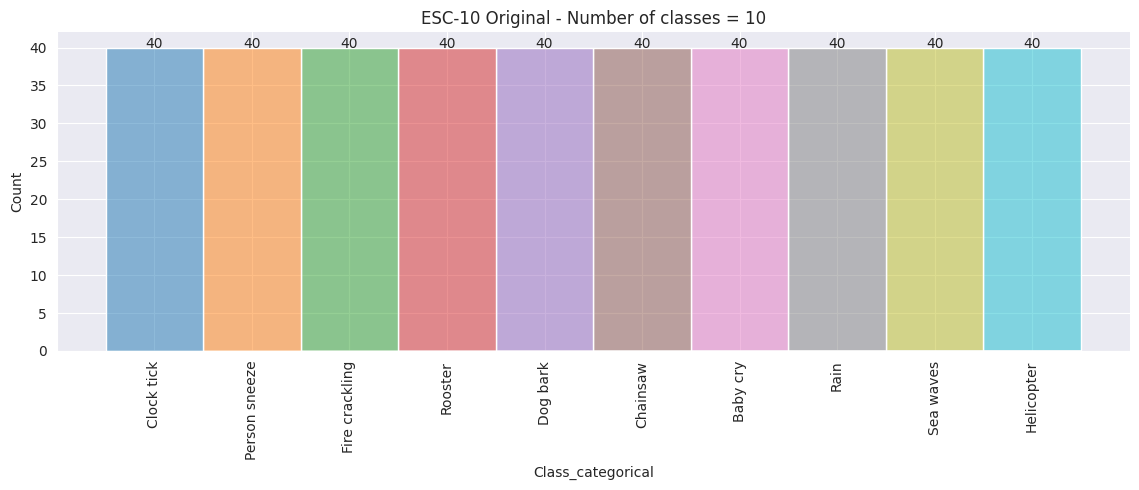

In [45]:
# Analysis of the class balancing

sns.set_style("darkgrid")
picture_name = f'{pic_first_name}{get_next_file_number(path_pic):02d}.png'
gTitle = nom_dataset + ' Original - Number of classes = ' + str(len(pd.Series(DB_ori_from_pkl['Class_categorical']).unique()))
g = sns.displot(DB_ori_from_pkl, x='Class_categorical', hue='Class_categorical',height = 5, aspect = 2).set(title=gTitle)
g.set_xticklabels(rotation=90)
g.set_titles('Number of classes')

# Retrieve the axes object from the plot
axes = g.ax

# Iterate over each bar in the plot
for p in axes.patches:
    # Get the coordinates of the bar
    width = p.get_width()
    height = p.get_height()
    cord_x, cord_y = p.get_xy()
    if height > 0:
        axes.annotate(f'{height}', (cord_x + width/2, cord_y + height), ha='center')
        
g._legend.remove()

plt.tight_layout()
plt.savefig(os.path.join(path_pic, picture_name))

### Features AUGMENTED

* *aug*       = True
* *windowing* = False

Dataset will be 6x larger (original + time stretching .85 / 1.15, pitch shifting -4 / +4 semitons, and time shifting randomly)

ATTENTION: you may need to split this process in more than 2 steps due memory allocation constrains

In [46]:
# For ESC-10 and BDLib2
if opc == 1 or opc == 2:
    
    # Remove silence samples, augment and normalize (windowed) the audio files

    audioPP_output = audioPP(db['Path'].values,
                             db['Class_categorical'].values, 
                             db['Class_OHEV'].values,
                             db['Fold'].values,
                             time_length = time_length,
                             threshold = threshold,
                             aug = True,
                             windowing = False,
                             frames = frames)
    
    X, y_string, y_OHEV, folds  = audioPP_output.audio_windowed, audioPP_output.labels_cat_wind, audioPP_output.labels_cod_wind, audioPP_output.labels_fold_wind

    y_OHEV = [np.array(eval(s)) for s in y_OHEV]
    
    db_aug = pd.DataFrame({'Audio' : X, 'Class_categorical' : y_string, 'Class_OHEV' : y_OHEV, 'Fold' : folds})
    db_aug[['Fold']] = db_aug[['Fold']].astype('str')

    
# For US8K due memory allocation constraints, the process must split the files, delete the variables and join them afterwards.
else:
    
    for i in range(2):
        subset_db = db[int(i*len(db)/2):int((i+1)*len(db)/2)]

        audioPP_output = audioPP(subset_db['Path'].values,
                                 subset_db['Class_categorical'].values, 
                                 subset_db['Class_OHEV'].values,
                                 subset_db['Fold'].values,
                                 time_length = time_length,
                                 threshold = threshold,
                                 aug = True,
                                 windowing = False,
                                 frames = frames)

        X, y_string, y_OHEV, folds  = audioPP_output.audio_windowed, audioPP_output.labels_cat_wind, audioPP_output.labels_cod_wind, audioPP_output.labels_fold_wind

        del subset_db # Delete to clear memory

        y_OHEV = [np.array(eval(s)) for s in y_OHEV]

        db_aug = pd.DataFrame({'Audio' : X, 'Class_categorical' : y_string, 'Class_OHEV' : y_OHEV, 'Fold' : folds})
        db_aug[['Fold']] = db_aug[['Fold']].astype('str')

        del X, y_string, y_OHEV, folds # Delete to clear memory

        # Save db_aug as a pickle file
        with open(os.path.join(path_models, f'db_aug_{i+1}.pkl'), 'wb') as f:
            pickle.dump(db_aug, f)

        del db_aug  # Delete db_aug to clear memory

    # Read and join both db_aug_1 and db_aug_2 into db_aug
    with open(os.path.join(path_models,'db_aug_1.pkl'), 'rb') as f:
        db_aug_1 = pickle.load(f)

    with open(os.path.join(path_models,'db_aug_2.pkl'), 'rb') as f:
        db_aug_2 = pickle.load(f)

    db_aug = pd.concat([db_aug_1, db_aug_2], ignore_index=True)

    del db_aug_1, db_aug_2
    os.remove(os.path.join(path_models,'db_aug_1.pkl'))
    os.remove(os.path.join(path_models,'db_aug_2.pkl'))

100%|██████████| 400/400 [00:37<00:00, 10.53it/s]
2400it [00:11, 204.79it/s]


Shape of the audio data..................: (2400, 110250)
Shape of the categorical label data......: (2400,)
Shape of the one hot encoder label data..: (2400,)
Shape of the fold data...................: (2400,)


In [47]:
print(type(db_aug['Fold'][0]))
print(type(db_aug['Class_OHEV'][0][0]))
print(type(db_aug['Class_OHEV'][0]))

<class 'str'>
<class 'numpy.int64'>
<class 'numpy.ndarray'>


In [48]:
db_aug['Audio'][random_idx*6] # 6x due augmentation to get the same sample as the original

array([-0.000381  , -0.00038467, -0.00032229, ...,  0.00353048,
       -0.00566175, -0.00294293], shape=(110250,), dtype=float32)

In [49]:
ipd.Audio(random_sample, rate = SR)

In [50]:
ipd.Audio(db_aug.at[random_idx*6 + 1, 'Audio'], rate = SR) # First augmentation of the original audio

In [51]:
librosa.get_duration(y = db_aug['Audio'][random_idx*6 + 1]) # 6x due augmentation to get the same sample as the original

5.0

In [52]:
pkl_aug_features

'ESC-10_features_augmented_no_windowing.pkl'

In [53]:
# Extract 375 features from the audio files (long process, strongly dependent on audio duration and its agumentation)

# Check if the pkl file exists, if not, create it
if not os.path.exists(os.path.join(path_models, pkl_aug_features)):
    Ft_extractor = feature_extractor(db_aug)
    DB_augmented = Ft_extractor.DB_aug
    
    # Check for NaN values in the entire DataFrame
    has_nan_columnwise = DB_augmented.isna().any(axis=0)

    # Print columns with NaN values
    print("Columns with NaN values:")
    print(has_nan_columnwise[has_nan_columnwise])
    
    DB_augmented.fillna(0, inplace=True)
    
    # Save the features to a pickle file (ESC-10: ~1,213GB, BDLib2: 1,088GB, US8K: ~21,218GB)
    DB_augmented.to_pickle(os.path.join(path_models, pkl_aug_features))
    
    # Read the features from the pickle file
    DB_aug_from_pkl = pd.read_pickle(os.path.join(path_models, pkl_aug_features))

# If exist, read the pkl file with the features extracted
else:
    DB_aug_from_pkl = pd.read_pickle(os.path.join(path_models, pkl_aug_features))

100%|██████████| 2400/2400 [15:09<00:00,  2.64it/s]


Columns with NaN values:
CHROMA_skew_2         True
CHROMA_kurtosis_2     True
CHROMA_skew_6         True
CHROMA_kurtosis_6     True
CHROMA_skew_10        True
CHROMA_kurtosis_10    True
dtype: bool


In [54]:
DB_aug_from_pkl

,Audio,Class_categorical,Class_OHEV,Fold,RMSE,ZCR,CENTROIDS,BANDWIDTH,ROLLOFF,MEL_1,...,TONNETZ_5,TONNETZ_std_5,TONNETZ_median_5,TONNETZ_skew_5,TONNETZ_kurtosis_5,TONNETZ_6,TONNETZ_std_6,TONNETZ_median_6,TONNETZ_skew_6,TONNETZ_kurtosis_6
0,"[-0.00023477469, -4.039734e-05, -0.00044840132, -0.0004541868, 0.0006202331, 0.00011244134, -0.00067169627, -0.00080...",Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",1,0.004566,0.139237,2380.802707,2564.477017,4960.811361,0.154683,...,0.014145,0.022668,0.014893,0.035355,0.059575,0.012487,0.025696,0.010993,0.373148,0.496386
1,"[-0.0017097329255193472, -0.001602938980795443, -0.0018617308232933283, -0.002419608412310481, -0.002380999736487865...",Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",1,0.004552,0.150486,2490.487637,2589.080193,5107.855225,0.153610,...,0.010690,0.025060,0.008785,-0.165092,-0.013194,0.017925,0.025979,0.015738,0.192757,0.119462
2,"[-0.00023516372, -4.998905e-05, -0.0004616848, -0.00046693784, 0.0006103019, 0.00010231196, -0.0006791068, -0.000804...",Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",1,0.002420,0.155730,2680.963527,2715.633097,5616.826375,0.012795,...,0.018470,0.030820,0.013827,1.493594,3.005124,0.004463,0.023420,0.000013,0.398532,-0.699007
3,"[-0.00023334876, -3.2386662e-05, -0.00043316014, -0.00044173485, 0.0006215063, 0.00012540062, -0.0006505925, -0.0007...",Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",1,0.003415,0.146055,2553.263375,2636.319348,5311.224365,0.103012,...,0.010866,0.031908,0.007073,0.208619,-0.540751,0.015361,0.038134,0.009672,0.320179,-0.283422
4,"[-0.0001680573, -0.00013271718, -0.00061601476, 0.0003546134, 0.00015024556, -0.00084576383, -0.00071913574, -0.0011...",Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",1,0.003362,0.149016,2528.408866,2641.345391,5327.673340,0.027700,...,-0.014669,0.023476,-0.012870,-0.062470,-0.780890,-0.013449,0.027284,-0.013858,0.061141,-0.859337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,"[0.0006072868372291238, -0.000855549415055185, -0.0006866504289068221, -0.0008739345690711422, 9.473955818201335e-05...",Helicopter,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]",5,0.251394,0.024061,771.944892,1680.835308,1008.521525,789.273571,...,-0.092008,0.022581,-0.091178,-0.496231,-0.487026,0.026373,0.021137,0.027488,-0.211096,-0.369753
2396,"[-0.004149724, -0.005646354, -0.004898626, -0.004094559, -0.003227883, -0.003087406, -0.0029074592, -0.0024209267, -...",Helicopter,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]",5,0.187576,0.009526,636.770966,1627.363136,736.914062,507.712524,...,-0.077522,0.026241,-0.073467,-0.314705,-1.097027,-0.025180,0.033085,-0.017357,-0.529249,-0.787355
2397,"[-0.00086795166, -0.0022453032, -0.0013754059, -0.0005514465, 0.000380154, 0.0006491668, 0.0010032736, 0.0015315245,...",Helicopter,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]",5,0.184278,0.010078,642.645577,1634.334537,727.842204,421.902100,...,-0.050021,0.017177,-0.051966,0.114582,-0.303767,0.064319,0.023877,0.064756,-0.030070,-0.838929
2398,"[-0.0045208996, -0.006646668, -0.005280685, -0.0044070706, -0.003930382, -0.0037389218, -0.0031581717, -0.002419361,...",Helicopter,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]",5,0.165891,0.013197,748.619654,1779.606301,992.072550,335.615753,...,0.059110,0.023526,0.054958,0.369855,-0.988778,0.037474,0.023387,0.032513,0.531478,0.007680


In [55]:
print(type(DB_aug_from_pkl['Fold'][0]))
print(type(DB_aug_from_pkl['Class_OHEV'][0][0]))
print(type(DB_aug_from_pkl['Class_OHEV'][0]))

<class 'str'>
<class 'numpy.int64'>
<class 'numpy.ndarray'>


In [56]:
print(len(DB_aug_from_pkl))

2400


In [57]:
DB_aug_from_pkl.shape

(2400, 379)

In [58]:
for i in DB_aug_from_pkl.columns:
    print(i)

Audio
Class_categorical
Class_OHEV
Fold
RMSE
ZCR
CENTROIDS
BANDWIDTH
ROLLOFF
MEL_1
MEL_2
MEL_3
MEL_4
MEL_5
MEL_6
MEL_7
MEL_8
MEL_9
MEL_10
MEL_11
MEL_12
MEL_13
MEL_14
MEL_15
MEL_16
MEL_17
MEL_18
MEL_19
MEL_20
MEL_21
MEL_22
MEL_23
MEL_24
MEL_25
MEL_26
MEL_27
MEL_28
MEL_29
MEL_30
MEL_31
MEL_32
MEL_33
MEL_34
MEL_35
MEL_36
MEL_37
MEL_38
MEL_39
MEL_40
MEL_41
MEL_42
MEL_43
MEL_44
MEL_45
MEL_46
MEL_47
MEL_48
MEL_49
MEL_50
MEL_51
MEL_52
MEL_53
MEL_54
MEL_55
MEL_56
MEL_57
MEL_58
MEL_59
MEL_60
MEL_61
MEL_62
MEL_63
MEL_64
MEL_65
MEL_66
MEL_67
MEL_68
MEL_69
MEL_70
MEL_71
MEL_72
MEL_73
MEL_74
MEL_75
MEL_76
MEL_77
MEL_78
MEL_79
MEL_80
MEL_81
MEL_82
MEL_83
MEL_84
MEL_85
MEL_86
MEL_87
MEL_88
MEL_89
MEL_90
MEL_91
MEL_92
MEL_93
MEL_94
MEL_95
MEL_96
MEL_97
MEL_98
MEL_99
MEL_100
MEL_101
MEL_102
MEL_103
MEL_104
MEL_105
MEL_106
MEL_107
MEL_108
MEL_109
MEL_110
MEL_111
MEL_112
MEL_113
MEL_114
MEL_115
MEL_116
MEL_117
MEL_118
MEL_119
MEL_120
MEL_121
MEL_122
MEL_123
MEL_124
MEL_125
MEL_126
MEL_127
MEL_128
MFCC_1


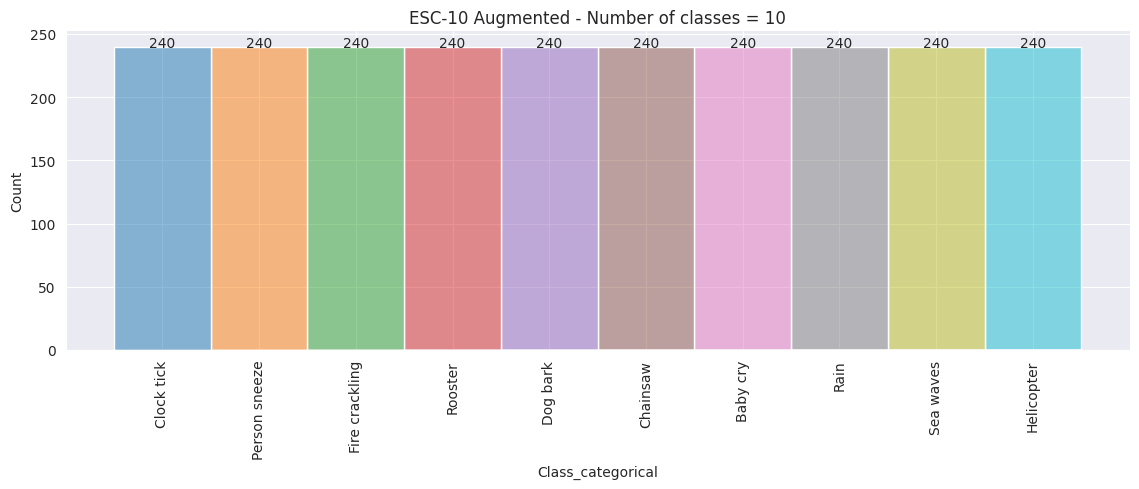

In [59]:
# Analysis of the class balancing

sns.set_style("darkgrid")
picture_name = f'{pic_first_name}{get_next_file_number(path_pic):02d}.png'
gTitle = nom_dataset + ' Augmented - Number of classes = ' + str(len(pd.Series(DB_aug_from_pkl['Class_categorical']).unique()))
g = sns.displot(DB_aug_from_pkl, x='Class_categorical', hue='Class_categorical',height = 5, aspect = 2).set(title=gTitle)
g.set_xticklabels(rotation=90)
g.set_titles('Number of classes')

# Retrieve the axes object from the plot
axes = g.ax

# Iterate over each bar in the plot
for p in axes.patches:
    # Get the coordinates of the bar
    width = p.get_width()
    height = p.get_height()
    cord_x, cord_y = p.get_xy()
    if height > 0:
        axes.annotate(f'{height}', (cord_x + width/2, cord_y + height), ha='center')
        
g._legend.remove()

plt.tight_layout()
plt.savefig(os.path.join(path_pic, picture_name))

### Features AUGMENTED and WINDOWED

* *aug*       = True (not for US8K)
* *windowing* = True

Check the globals (*aug_set*, *wind_set*) in the beginning of the notebook

Initially, the dataset will be 6x larger (original + time stretching .85 / 1.15, pitch shifting -4 / +4 semitons, and time shifting randomly).

Windowing process depends on the dataset: 9 for ESC-10, 19 for BDLib2, and 7 for USK8K.

Final datasets will have:

* ESC-10 = 6 agumentations * 9  windows * 400 samples   = **21,600 samples**
* BDLib2 = 6 agumentations * 19 windows * 180 samples   = **20,520 samples**
* US8K   = 0 agumentations * 7 window   * 8,732 samples = **61,124 samples**

ATTENTION: you may need to split this process due memory allocation constrains

In [60]:
# Clear the memory
del db_aug, DB_ori_from_pkl, DB_aug_from_pkl

In [61]:
# Remove silence samples, augment and normalize (windowed) the audio files

audioPP_output = audioPP(db['Path'].values,
                         db['Class_categorical'].values, 
                         db['Class_OHEV'].values,
                         db['Fold'].values,
                         time_length = time_length,
                         threshold = threshold,
                         aug = aug_set,
                         windowing = wind_set,
                         frames = frames)
    
X, y_string, y_OHEV, folds  = audioPP_output.audio_windowed, audioPP_output.labels_cat_wind, audioPP_output.labels_cod_wind, audioPP_output.labels_fold_wind

100%|██████████| 400/400 [00:37<00:00, 10.71it/s]
2400it [00:12, 199.34it/s]
100%|██████████| 2400/2400 [00:00<00:00, 148379.02it/s]


Shape of the audio data..................: (21600, 22016)
Shape of the categorical label data......: (21600,)
Shape of the one hot encoder label data..: (21600,)
Shape of the fold data...................: (21600,)


In [62]:
y_OHEV = [np.array(eval(s)) for s in y_OHEV]

In [63]:
db_aug = pd.DataFrame({'Audio' : X, 'Class_categorical' : y_string, 'Class_OHEV' : y_OHEV, 'Fold' : folds})
db_aug[['Fold']] = db_aug[['Fold']].astype('str')

In [64]:
print(type(db_aug['Fold'][0]))
print(type(db_aug['Class_OHEV'][0][0]))
print(type(db_aug['Class_OHEV'][0]))

<class 'str'>
<class 'numpy.int64'>
<class 'numpy.ndarray'>


In [65]:
ipd.Audio(random_sample, rate = SR)

In [66]:
random_idx

177

In [67]:
# For ESC-10 and BDLib2
print(librosa.get_duration(y = db_aug.at[random_idx * 6 * windowingNo, 'Audio']))
ipd.Audio(db_aug.at[random_idx * 6 * windowingNo + 1, 'Audio'], rate = SR)

0.9984580498866213


In [68]:
# For US8K
print(librosa.get_duration(y = db_aug.at[random_idx * 1 * windowingNo, 'Audio']))
ipd.Audio(db_aug.at[random_idx * 1 * windowingNo, 'Audio'], rate = SR)

0.9984580498866213


In [69]:
pkl_aug_wind_features

'ESC-10_features_augmented.pkl'

In [70]:
# Extract 375 features from the audio files (long process, strongly dependent on audio duration and its agumentation)

# Check if the pkl file exists, if not, create it
if not os.path.exists(os.path.join(path_models, pkl_aug_wind_features)):
    Ft_extractor = feature_extractor(db_aug)
    DB_aug_wind  = Ft_extractor.DB_aug
    
    # Check for NaN values in the entire DataFrame
    has_nan_columnwise = DB_aug_wind.isna().any(axis=0)

    # Print columns with NaN values
    print("Columns with NaN values:")
    print(has_nan_columnwise[has_nan_columnwise])
    
    DB_aug_wind.fillna(0, inplace=True)
    
    # Save the features to a pickle file (ESC-10: ~2,232GB, BDLib2: ~2,121GB, US8K: ~5,442GB)
    DB_aug_wind.to_pickle(os.path.join(path_models, pkl_aug_wind_features)) 
    
    # Read the features from the pickle file
    DB_aug_wind_from_pkl = pd.read_pickle(os.path.join(path_models, pkl_aug_wind_features))

# If exist, read the pkl file with the features extracted
else:
    DB_aug_wind_from_pkl = pd.read_pickle(os.path.join(path_models, pkl_aug_wind_features))

100%|██████████| 21600/21600 [1:21:30<00:00,  4.42it/s]


Columns with NaN values:
CHROMA_skew_1         True
CHROMA_kurtosis_1     True
CHROMA_skew_2         True
CHROMA_kurtosis_2     True
CHROMA_skew_3         True
CHROMA_kurtosis_3     True
CHROMA_skew_4         True
CHROMA_kurtosis_4     True
CHROMA_skew_5         True
CHROMA_kurtosis_5     True
CHROMA_skew_6         True
CHROMA_kurtosis_6     True
CHROMA_skew_7         True
CHROMA_kurtosis_7     True
CHROMA_skew_8         True
CHROMA_kurtosis_8     True
CHROMA_skew_9         True
CHROMA_kurtosis_9     True
CHROMA_skew_10        True
CHROMA_kurtosis_10    True
CHROMA_skew_11        True
CHROMA_kurtosis_11    True
CHROMA_skew_12        True
CHROMA_kurtosis_12    True
dtype: bool


In [71]:
DB_aug_wind_from_pkl

,Audio,Class_categorical,Class_OHEV,Fold,RMSE,ZCR,CENTROIDS,BANDWIDTH,ROLLOFF,MEL_1,...,TONNETZ_5,TONNETZ_std_5,TONNETZ_median_5,TONNETZ_skew_5,TONNETZ_kurtosis_5,TONNETZ_6,TONNETZ_std_6,TONNETZ_median_6,TONNETZ_skew_6,TONNETZ_kurtosis_6
0,"[-0.00023477469, -4.039734e-05, -0.00044840132, -0.0004541868, 0.0006202331, 0.00011244134, -0.00067169627, -0.00080...",Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",1,0.002834,0.172385,3195.317997,3025.714898,6881.326571,0.015759,...,0.014494,0.030655,0.018970,-0.330288,-1.229000,0.005563,0.013776,0.004655,0.266444,-0.770466
1,"[-0.0008195563, 0.00016358378, -0.0015148204, -0.00034830114, 0.001450052, -0.0001384037, -0.00041916088, -8.688799e...",Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",1,0.002006,0.194758,3212.361287,2886.926162,6573.254949,0.001775,...,0.038685,0.027965,0.030713,0.827434,-0.244967,0.038488,0.017169,0.042418,0.371805,0.279209
2,"[-6.178976e-05, -5.656014e-05, -8.545804e-05, -3.209362e-05, 1.6888309e-05, 8.768431e-06, -1.572945e-05, -1.9051568e...",Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",1,0.002282,0.165350,2634.510876,2687.202902,5410.951372,0.004481,...,0.033620,0.022424,0.028333,1.362317,1.785421,0.005777,0.020466,-0.001779,0.921322,-0.237088
3,"[-0.00041403377, -6.365767e-05, -0.00045042997, -0.0013043337, -0.0013196887, -0.0007899666, -0.00055761356, -0.0009...",Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",1,0.003242,0.154053,2603.593731,2737.675053,5547.980846,0.025944,...,0.033685,0.008894,0.034968,-0.270708,-0.944085,0.000021,0.011547,0.001652,-0.374238,-0.875323
4,"[0.0032840336, 0.0029332386, 0.0033469512, 0.0033489682, 0.0032051695, 0.0028063194, 0.003165105, 0.0032094542, 0.00...",Clock tick,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",1,0.003358,0.198642,2984.205947,2918.207618,6612.895619,0.023849,...,0.028770,0.010117,0.029682,-0.635782,-0.438618,0.000663,0.020231,0.003529,-0.320069,-1.097383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21595,"[-0.032334723, -0.04189167, -0.049385548, -0.05417461, -0.057319213, -0.06397827, -0.0756218, -0.083919235, -0.08642...",Helicopter,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]",5,0.169035,0.008390,554.765797,1356.612448,726.745605,404.183014,...,0.001677,0.025757,0.000147,0.100721,-1.497190,-0.075934,0.017620,-0.068845,-0.600447,-1.018817
21596,"[0.37115946, 0.369348, 0.35838762, 0.34956977, 0.34757665, 0.34737659, 0.34815633, 0.34847233, 0.34823453, 0.3516483...",Helicopter,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]",5,0.154127,0.007413,610.054850,1425.966297,891.915061,276.958282,...,-0.010422,0.015861,-0.004669,-0.342826,-1.572058,-0.035490,0.010845,-0.035797,0.133858,-1.005102
21597,"[0.29142356, 0.29112947, 0.2870928, 0.2791608, 0.2808168, 0.28720585, 0.28625327, 0.28228772, 0.2812715, 0.28390378,...",Helicopter,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]",5,0.150969,0.009943,618.792476,1440.364681,890.936279,274.430206,...,0.012645,0.016172,0.017295,-0.869690,-0.547563,-0.047979,0.018916,-0.048906,0.011071,-1.369146
21598,"[-0.10181691, -0.10380417, -0.110239744, -0.103285, -0.08803459, -0.083140865, -0.08652803, -0.08545593, -0.08214281...",Helicopter,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]",5,0.160269,0.010076,581.217735,1388.260198,794.526256,353.277557,...,-0.021712,0.014117,-0.027275,0.128261,-1.439081,-0.037427,0.009498,-0.039441,0.173122,-1.538824


In [72]:
print(type(DB_aug_wind_from_pkl['Fold'][0]))
print(type(DB_aug_wind_from_pkl['Class_OHEV'][0][0]))
print(type(DB_aug_wind_from_pkl['Class_OHEV'][0]))

<class 'str'>
<class 'numpy.int64'>
<class 'numpy.ndarray'>


In [73]:
print(len(DB_aug_wind_from_pkl))

21600


In [74]:
DB_aug_wind_from_pkl.shape

(21600, 379)

In [75]:
for i in DB_aug_wind_from_pkl.columns:
    print(i)

Audio
Class_categorical
Class_OHEV
Fold
RMSE
ZCR
CENTROIDS
BANDWIDTH
ROLLOFF
MEL_1
MEL_2
MEL_3
MEL_4
MEL_5
MEL_6
MEL_7
MEL_8
MEL_9
MEL_10
MEL_11
MEL_12
MEL_13
MEL_14
MEL_15
MEL_16
MEL_17
MEL_18
MEL_19
MEL_20
MEL_21
MEL_22
MEL_23
MEL_24
MEL_25
MEL_26
MEL_27
MEL_28
MEL_29
MEL_30
MEL_31
MEL_32
MEL_33
MEL_34
MEL_35
MEL_36
MEL_37
MEL_38
MEL_39
MEL_40
MEL_41
MEL_42
MEL_43
MEL_44
MEL_45
MEL_46
MEL_47
MEL_48
MEL_49
MEL_50
MEL_51
MEL_52
MEL_53
MEL_54
MEL_55
MEL_56
MEL_57
MEL_58
MEL_59
MEL_60
MEL_61
MEL_62
MEL_63
MEL_64
MEL_65
MEL_66
MEL_67
MEL_68
MEL_69
MEL_70
MEL_71
MEL_72
MEL_73
MEL_74
MEL_75
MEL_76
MEL_77
MEL_78
MEL_79
MEL_80
MEL_81
MEL_82
MEL_83
MEL_84
MEL_85
MEL_86
MEL_87
MEL_88
MEL_89
MEL_90
MEL_91
MEL_92
MEL_93
MEL_94
MEL_95
MEL_96
MEL_97
MEL_98
MEL_99
MEL_100
MEL_101
MEL_102
MEL_103
MEL_104
MEL_105
MEL_106
MEL_107
MEL_108
MEL_109
MEL_110
MEL_111
MEL_112
MEL_113
MEL_114
MEL_115
MEL_116
MEL_117
MEL_118
MEL_119
MEL_120
MEL_121
MEL_122
MEL_123
MEL_124
MEL_125
MEL_126
MEL_127
MEL_128
MFCC_1


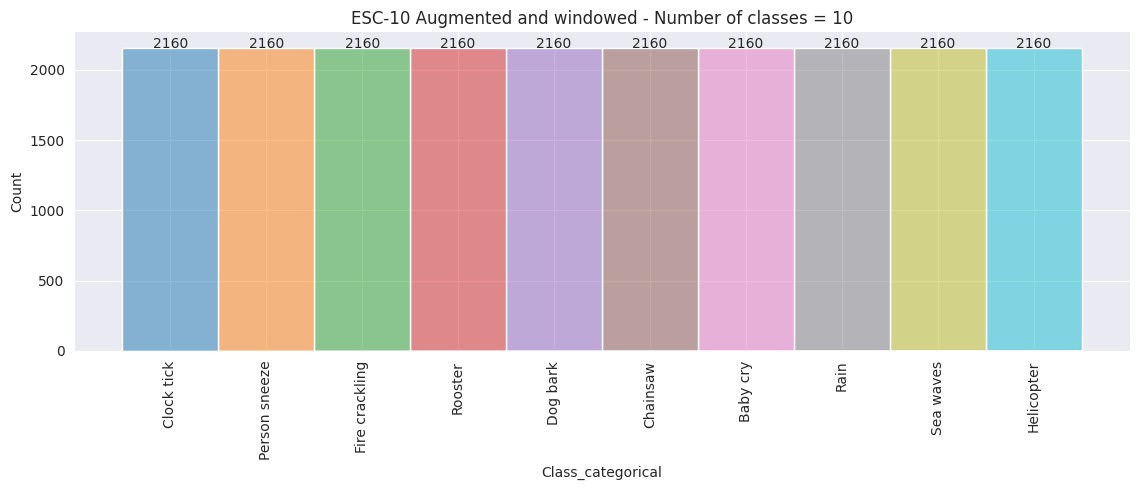

In [76]:
# Analysis of the class balancing

sns.set_style("darkgrid")
picture_name = f'{pic_first_name}{get_next_file_number(path_pic):02d}.png'
gTitle = nom_dataset + ' Augmented and windowed - Number of classes = ' + str(len(pd.Series(DB_aug_wind_from_pkl['Class_categorical']).unique()))
g = sns.displot(DB_aug_wind_from_pkl, x='Class_categorical', hue='Class_categorical',height = 5, aspect = 2).set(title=gTitle)
g.set_xticklabels(rotation=90)
g.set_titles('Number of classes')

# Retrieve the axes object from the plot
axes = g.ax

# Iterate over each bar in the plot
for p in axes.patches:
    # Get the coordinates of the bar
    width = p.get_width()
    height = p.get_height()
    cord_x, cord_y = p.get_xy()
    if height > 0:
        axes.annotate(f'{height}', (cord_x + width/2, cord_y + height), ha='center')
        
g._legend.remove()

plt.tight_layout()
plt.savefig(os.path.join(path_pic, picture_name))

## Features analysis

In [77]:
DB_ori_from_pkl = pd.read_pickle(os.path.join(path_models, pkl_features))

In [78]:
# Method to parse each row and extract the defined audio feature

def MFCC_parser(row): 
    # Number of MFCCs
    n_mfcc = 13
   
    # 13 x frames matrix
    mfcc = librosa.feature.mfcc(y = row.Audio, sr = SR, n_mfcc = n_mfcc)
    for i in range(0, n_mfcc):
        row[f'MFCC_{i+1}'] = np.array(mfcc[i])
  
    return row

In [79]:
# Method to parse each row and extract the defined audio feature

def TONNETZ_parser(row): 

    # 6 x frames matrix
    tonnetz    = librosa.feature.tonnetz(y = librosa.effects.harmonic(row.Audio), sr = SR)
    tonnetz_sp = np.shape(tonnetz)
    for i in range(0, tonnetz_sp[0]):
        row[f'TONNETZ_{i+1}'] = np.array(tonnetz[i])    

    return row

In [80]:
# Method to parse each row and extract the defined audio feature

def MEL_parser(row): 
    # Number of MELs    
    n_mels = 128

    # 128 x frames matrix
    mel = librosa.feature.melspectrogram(y = row.Audio, hop_length = HOP_LENGTH, n_fft = 2048, sr = SR, n_mels = n_mels)
    for i in range(0, n_mels):
        row[f'MEL_{i+1}'] = np.array(mel[i])

    return row

In [81]:
# Method to parse each row and extract the defined audio feature

def CONTRAST_parser(row): 

    # 7 x frames matrix
    spec_contrast    = librosa.feature.spectral_contrast(y = row.Audio, hop_length = HOP_LENGTH, n_fft = 2048, sr = SR)
    spec_contrast_sp = np.shape(spec_contrast)
    for i in range(0, spec_contrast_sp[0]):
        row[f'CONSTRAST_{i+1}'] = np.array(spec_contrast[i])

    return row

In [82]:
# Method to parse each row and extract the defined audio feature

def CHROMA_parser(row): 

    # 12 x frames matrix
    chroma    = librosa.feature.chroma_stft(y = row.Audio, hop_length = HOP_LENGTH, n_fft = 2048, sr = SR)
    chroma_sp = np.shape(chroma)
    for i in range(0, chroma_sp[0]):
        row[f'CHROMA_{i+1}'] = np.array(chroma[i])

    return row

In [83]:
MFCC_columns      = list(DB_ori_from_pkl.filter(regex='MFCC_\d', axis=1).columns)
TONNETZ_columns   = list(DB_ori_from_pkl.filter(regex='^TONNETZ_\d', axis=1).columns)
MEL_columns       = list(DB_ori_from_pkl.filter(regex='^MEL_\d', axis=1).columns)
CONSTRAST_columns = list(DB_ori_from_pkl.filter(regex='^CONSTRAST_\d', axis=1).columns)
CHROMA_columns    = list(DB_ori_from_pkl.filter(regex='^CHROMA_\d', axis=1).columns)

In [84]:
def plot_MFCC_features(feature_def, lin: int, columns: list):

    picture_name = f'{pic_first_name}{get_next_file_number(path_pic):02d}.png'
    
    dfSample = pd.DataFrame(DB_ori_from_pkl[lin:lin+1]).apply(feature_def, axis = 1)
    sample   = str(DB_ori_from_pkl.at[lin, 'Class_categorical'])

    f = plt.figure(figsize=(20, 12))
    sns.boxplot(dfSample.apply(lambda x: pd.Series(x.values[0])), orient = "h", order=list(reversed(columns)))
    plt.title(f'{nom_dataset} - MFCCs distribution across frames of a single audio file, class: {sample}')
    plt.savefig(os.path.join(path_pic, picture_name))

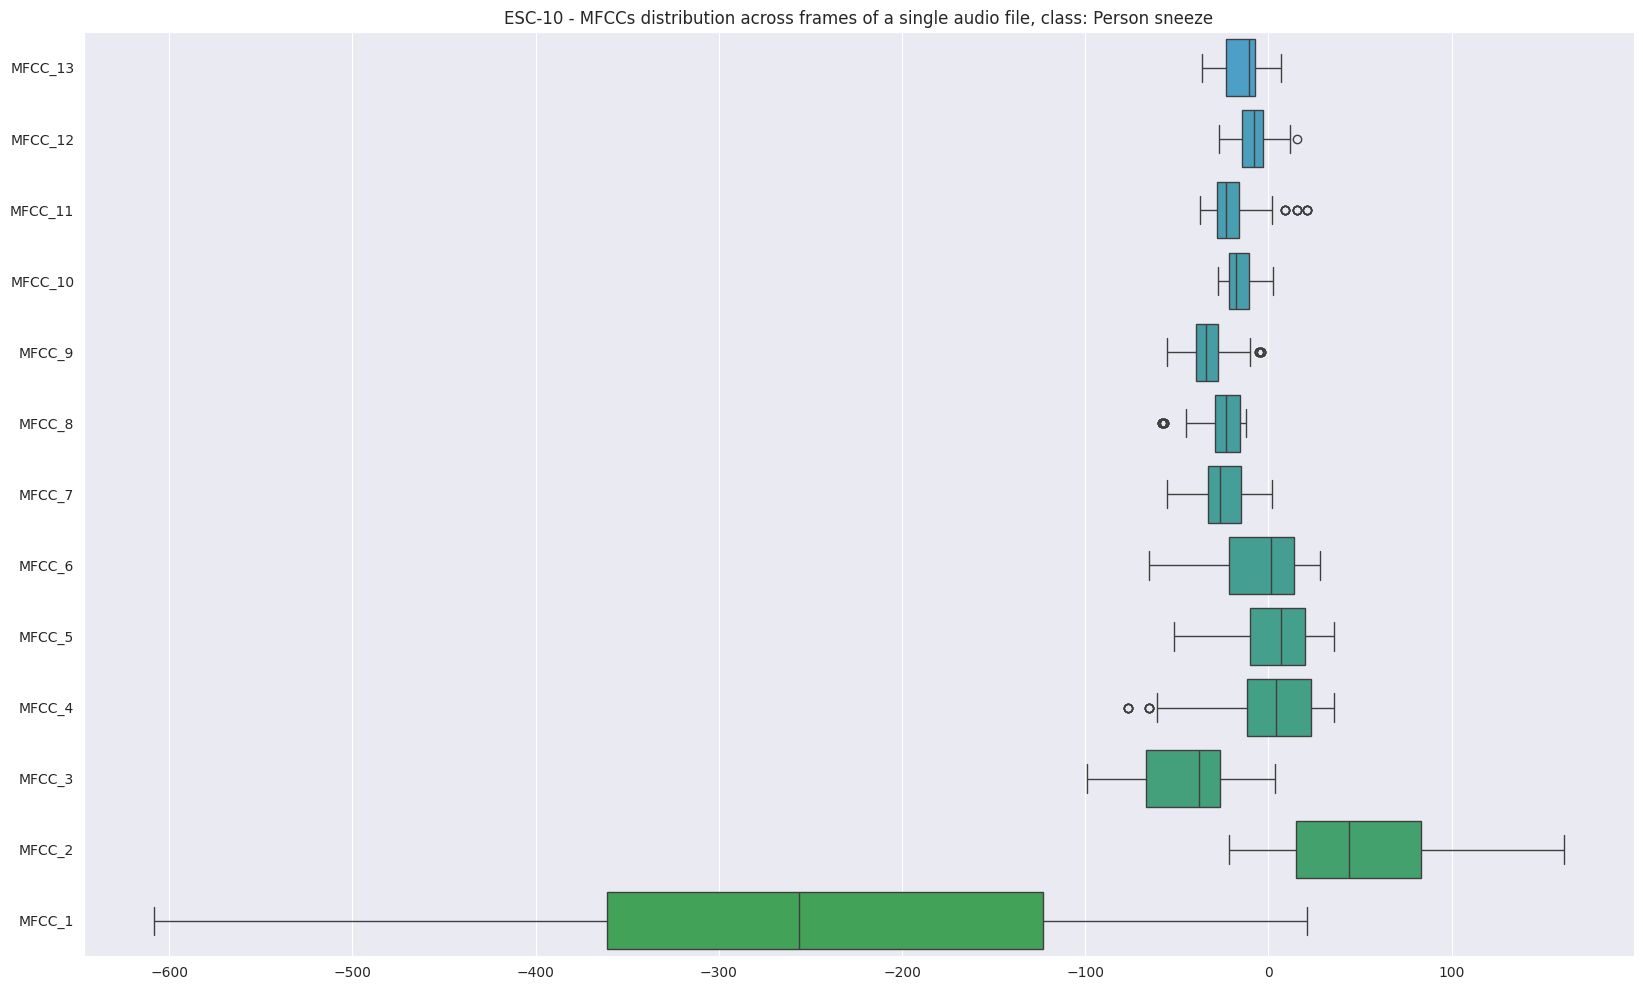

In [85]:
plot_MFCC_features(MFCC_parser, 50, MFCC_columns)

In [86]:
DB_ori_from_pkl['Class_categorical']

0      Clock tick
1      Clock tick
2      Clock tick
3      Clock tick
4      Clock tick
          ...    
395    Helicopter
396    Helicopter
397    Helicopter
398    Helicopter
399    Helicopter
Name: Class_categorical, Length: 400, dtype: object

In [87]:
dfTONNETZ   = DB_ori_from_pkl.filter(regex=r'^TONNETZ_\d', axis=1)
dfMEL       = DB_ori_from_pkl.filter(regex=r'^MEL_\d', axis=1)
dfCONSTRAST = DB_ori_from_pkl.filter(regex=r'^CONTRAST_\d', axis=1)
dfCHROMA    = DB_ori_from_pkl.filter(regex=r'^CHROMA_\d', axis=1)
dfMFCC      = DB_ori_from_pkl.filter(regex=r'^MFCC_\d', axis=1)

In [88]:
dfTONNETZ.insert(0, 'Class_categorical', DB_ori_from_pkl['Class_categorical'])
dfMEL.insert(0, 'Class_categorical', DB_ori_from_pkl['Class_categorical'])
dfCONSTRAST.insert(0, 'Class_categorical', DB_ori_from_pkl['Class_categorical'])
dfCHROMA.insert(0, 'Class_categorical', DB_ori_from_pkl['Class_categorical'])
dfMFCC.insert(0, 'Class_categorical', DB_ori_from_pkl['Class_categorical'])

In [89]:
def plot_features(db: pd.DataFrame, feature_name:str, lin:int):

    picture_name = f'{pic_first_name}{get_next_file_number(path_pic):02d}.png'

    sample   = str(db.at[lin, 'Class_categorical'])
    dfSample = db.drop(columns=['Class_categorical'])
    
    f = plt.figure(figsize=(20, 12))
    sns.boxplot(dfSample.apply(lambda x: pd.Series(x.values[0])), orient = "h", order=list(reversed(dfSample.columns)))
    plt.title(f'{nom_dataset} - {feature_name} distribution across frames of a single audio file, class: {sample}')
    plt.savefig(os.path.join(path_pic, picture_name))

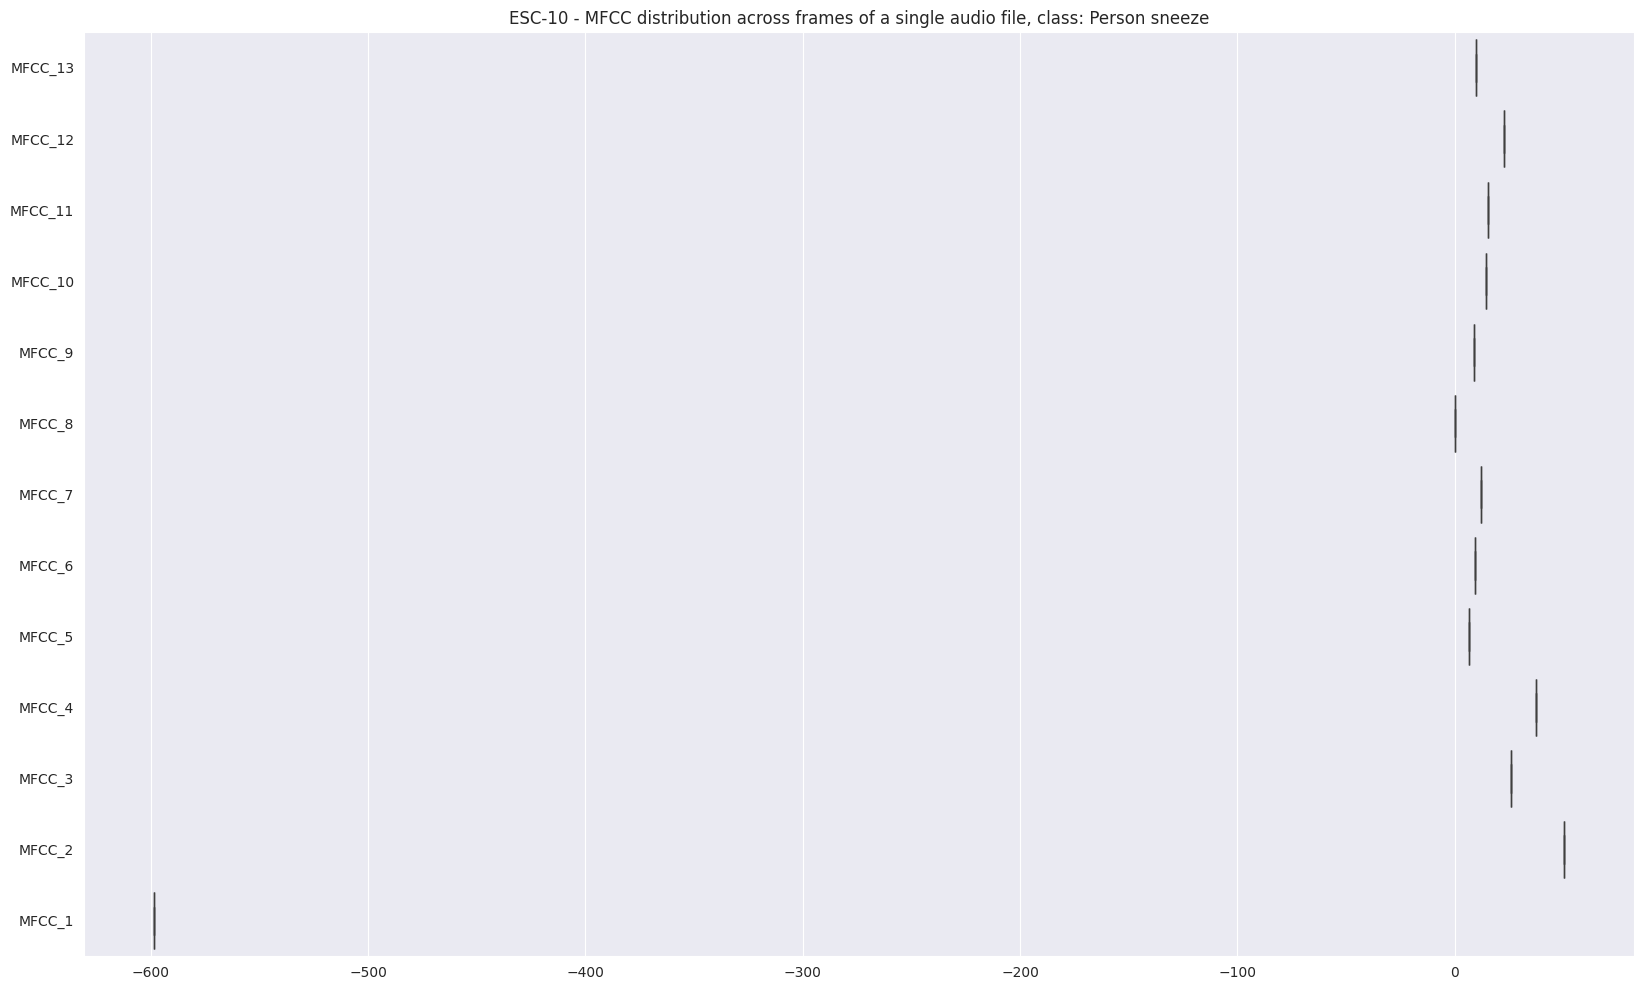

In [90]:
plot_features(dfMFCC, 'MFCC', 50)

In [91]:
audio_samples = DB_ori_from_pkl.groupby('Class_categorical')['Audio'].apply(lambda s: s.sample(1))
sampled_indices = np.array(audio_samples.index)
sampled_indices

# Convert the resulting Series to a DataFrame and reset the index
#temp_sample_df = audio_samples.reset_index()

# Convert the DataFrame to a NumPy array
#plot_samples   = temp_sample_df[['Class_categorical', 'Audio']].values
#plot_samples

array([('Baby cry', 271), ('Chainsaw', 218), ('Clock tick', 5),
       ('Dog bark', 169), ('Fire crackling', 86), ('Helicopter', 393),
       ('Person sneeze', 41), ('Rain', 300), ('Rooster', 141),
       ('Sea waves', 339)], dtype=object)

In [92]:
DB_ori_from_pkl.at[120,'Class_categorical']

'Rooster'

In [93]:
sampled_indices.shape[0]

10

In [94]:
# Plot the MFCC features of each class sample
    
def plot_MFCC_audio_sample(data: list):
    
    picture_name = f'{pic_first_name}{get_next_file_number(path_pic):02d}.png'

    fig, axes = plt.subplots(int(np.ceil(np.shape(data)[0] / 2)), 2, 
                             figsize=(20, (np.ceil(data.shape[0] / 2))*6),
                            layout='constrained')
    fig.suptitle(f'{nom_dataset} - MFCC features for each class sample', fontsize = 14)
    fig.subplots_adjust(top=0.9, hspace=0.1)

    for i, ax in enumerate(axes.flatten()):
        if i < np.shape(data)[0]:
            
            dfSample = pd.DataFrame(DB_ori_from_pkl[data[i][1]:data[i][1]+1]).apply(MFCC_parser, axis = 1)
            sample   = data[i][0]

            img = sns.boxplot(dfSample.apply(lambda x: pd.Series(x.values[0])),
                              ax     = ax,
                              orient = "h", 
                              order  = list(reversed(MFCC_columns)))
            ax.set_title(f'Sample {i+1}, class {sample}') 

        else:
            ax.axis('off') 
            
    fig.tight_layout(pad = 2.0)
    plt.savefig(os.path.join(path_pic, picture_name))
    plt.show()

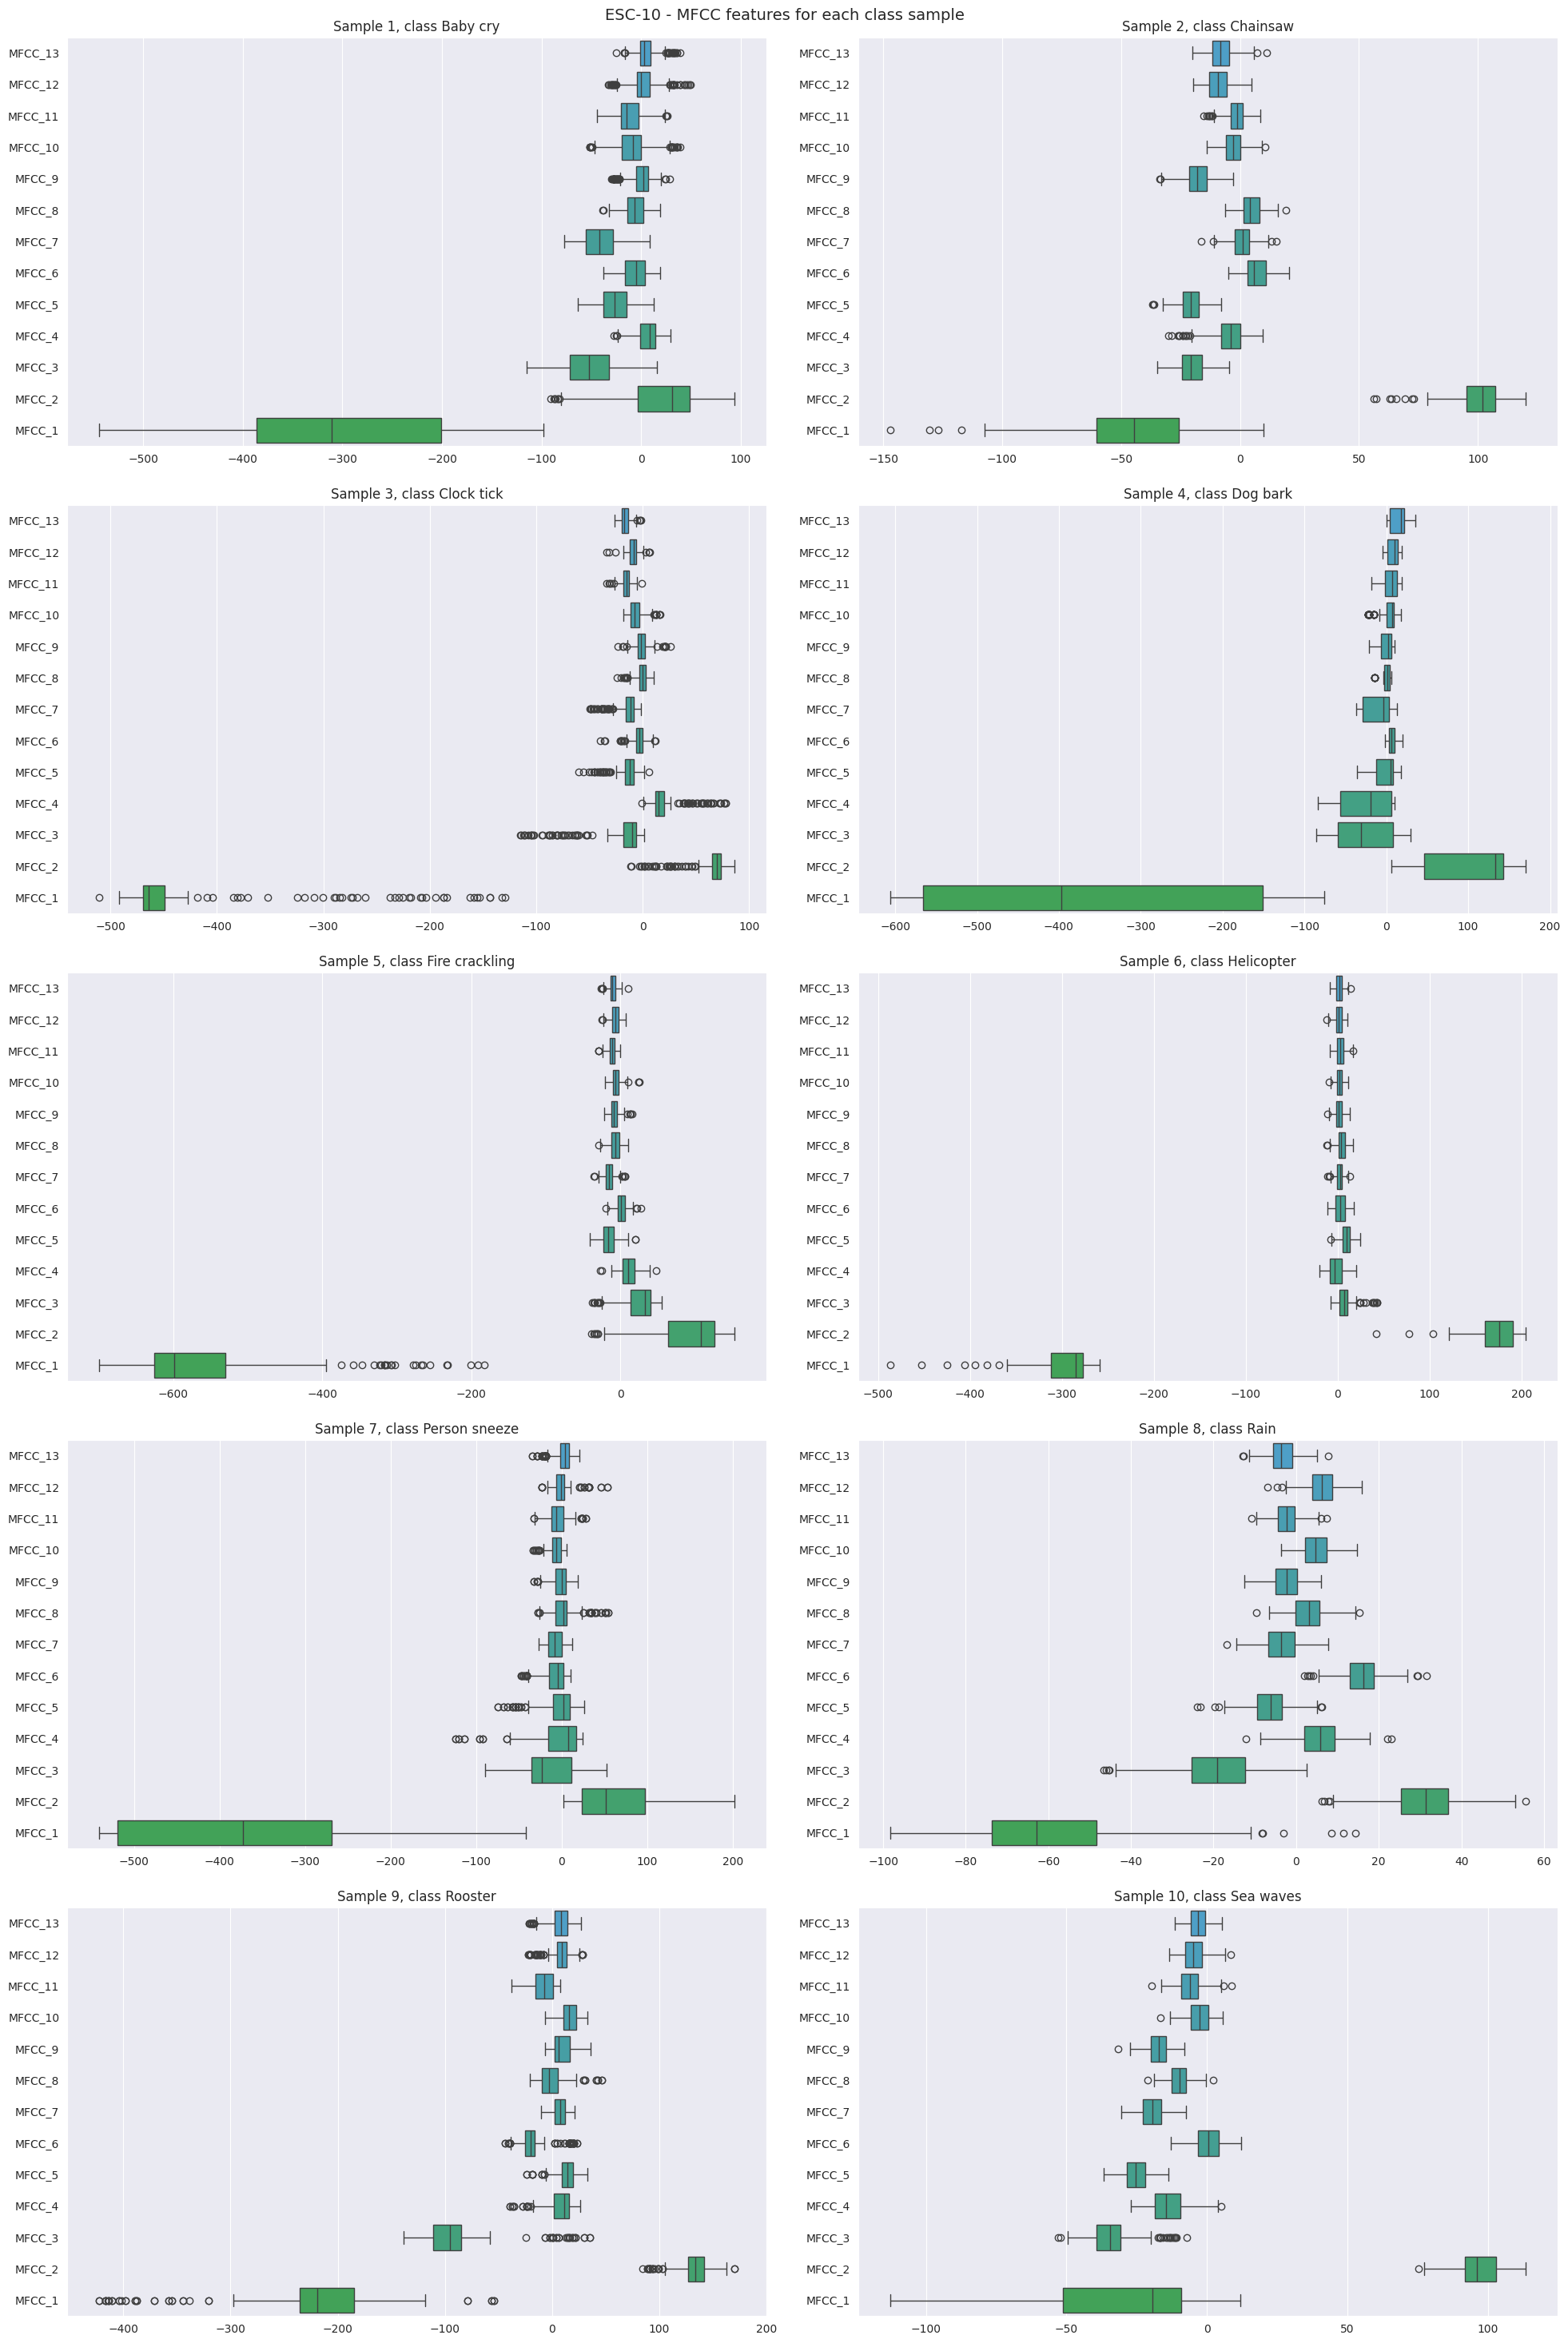

In [95]:
plot_MFCC_audio_sample(sampled_indices)

In [96]:
# Group by the class and get one random sample of each class
k = DB_ori_from_pkl.groupby('Class_categorical')['Class_OHEV'].apply(lambda s: s.sample(1))
print(k)

# Convert the pandas series into a dataframe
temp_k_df = k.reset_index()

# Delete the index from the grouppby result
del temp_k_df['level_1']

# Set the "Class" as the dataframe index
temp_k_df.set_index("Class_categorical", inplace=True)

# Convert the dataframe to a dictionary (Class: Class_encoder)
encoder_dict = temp_k_df["Class_OHEV"].to_dict()
encoder_dict

Class_categorical     
Baby cry           255    [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Chainsaw           231    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
Clock tick         26     [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
Dog bark           177    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
Fire crackling     89     [0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
Helicopter         390    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
Person sneeze      68     [0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
Rain               293    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
Rooster            126    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
Sea waves          340    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
Name: Class_OHEV, dtype: object


{'Baby cry': array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'Chainsaw': array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0]),
 'Clock tick': array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0]),
 'Dog bark': array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0]),
 'Fire crackling': array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0]),
 'Helicopter': array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0]),
 'Person sneeze': array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0]),
 'Rain': array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0]),
 'Rooster': array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0]),
 'Sea waves': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1])}

In [97]:
nom_classes = list(encoder_dict.keys())
nom_classes

['Baby cry',
 'Chainsaw',
 'Clock tick',
 'Dog bark',
 'Fire crackling',
 'Helicopter',
 'Person sneeze',
 'Rain',
 'Rooster',
 'Sea waves']

# End of notebook